In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import dlib

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

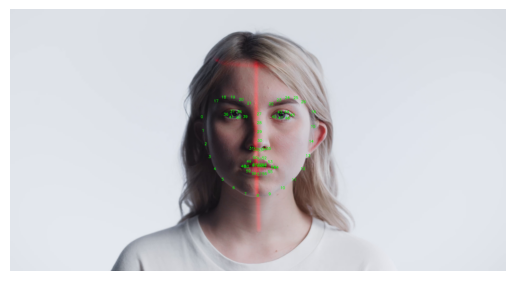

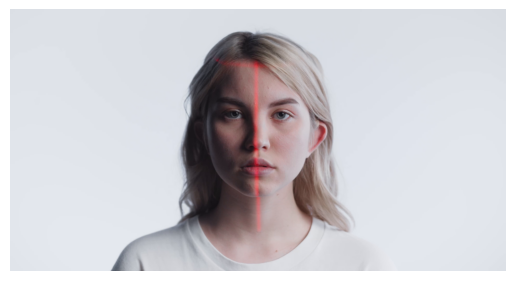

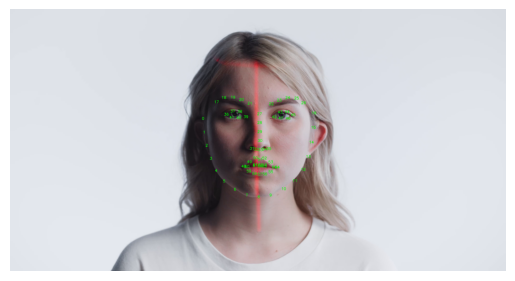

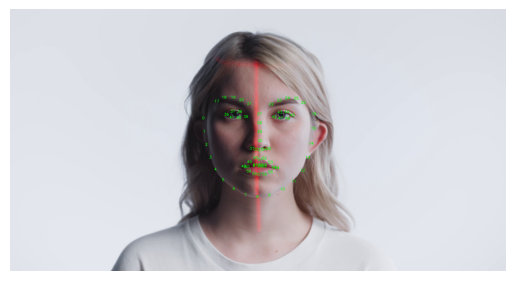

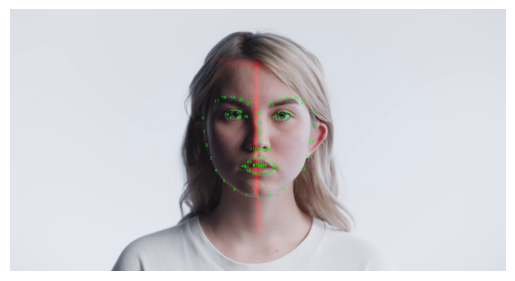

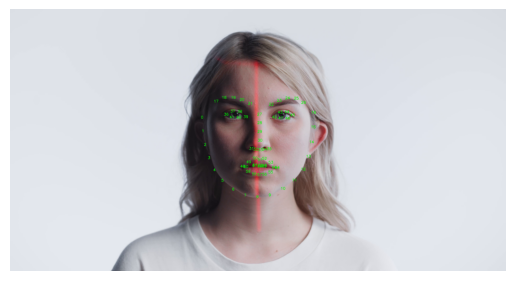

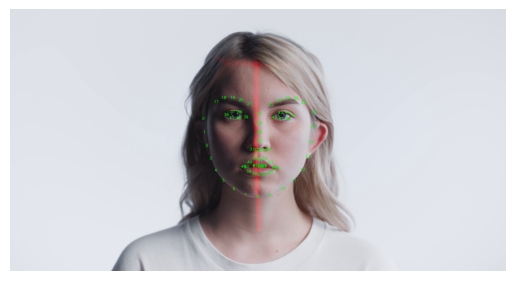

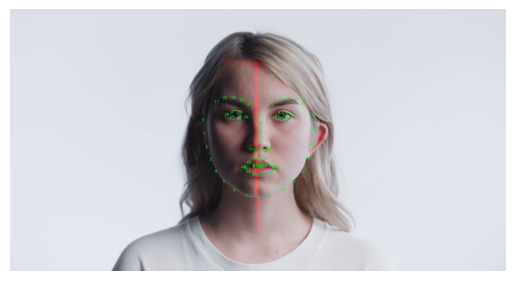

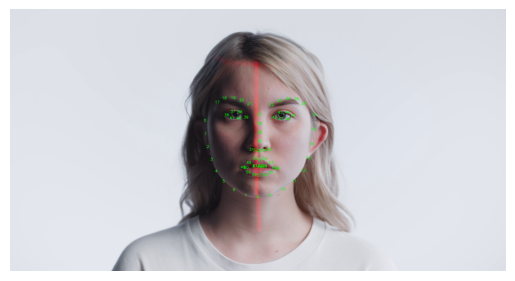

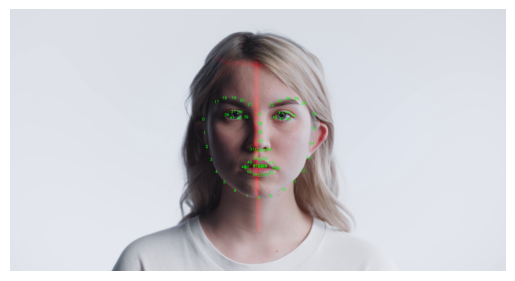

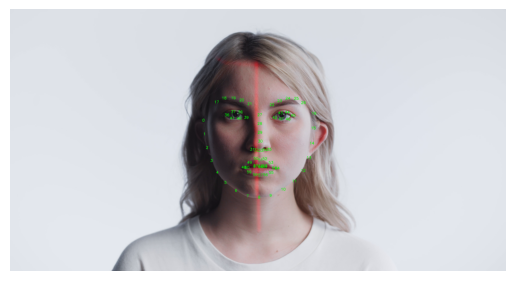

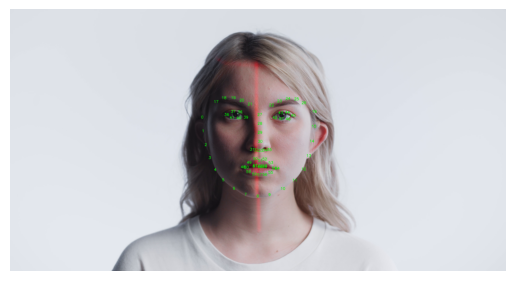

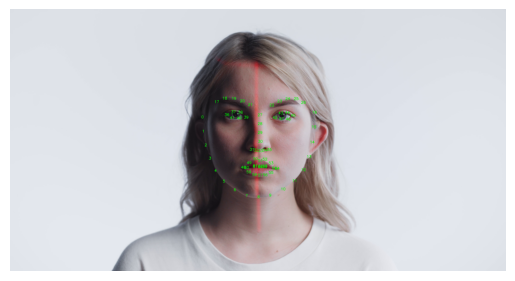

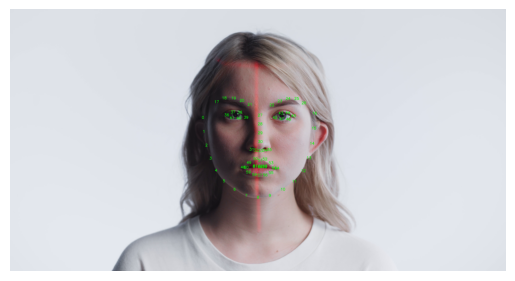

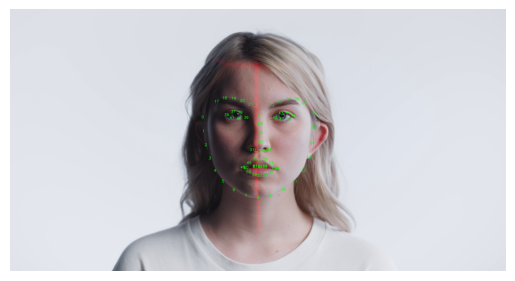

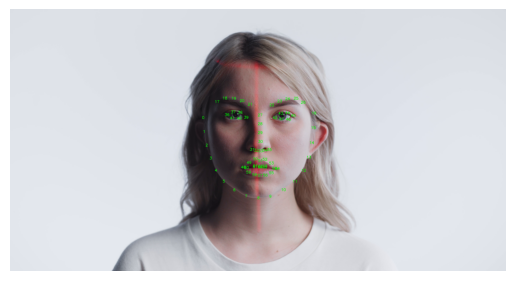

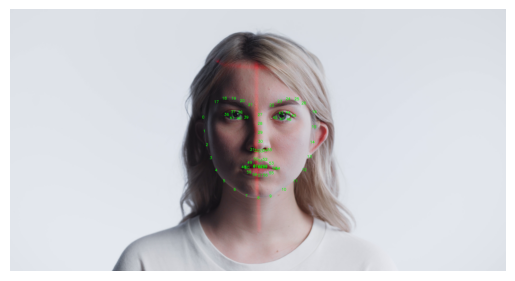

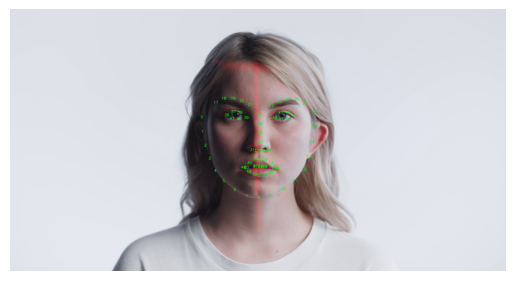

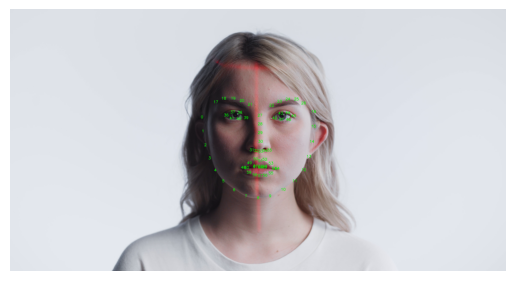

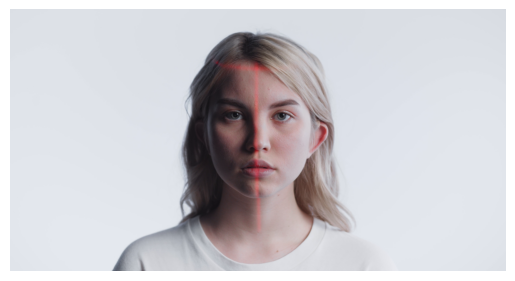

In [8]:

# Load Dlib face detector
detector = dlib.get_frontal_face_detector()


# Load pretrained 68 facial landmark model
# ----------------------------------------------------
predictor = dlib.shape_predictor(
    "/content/drive/MyDrive/Colab Notebooks/videos/shape_predictor_68_face_landmarks.dat"
)


# Open video (or replace 0 with webcam)
cap = cv.VideoCapture("/content/drive/MyDrive/Colab Notebooks/videos/face.mp4")

for i in range(20):

    # Read next frame
    ret, frame = cap.read()

    if not ret:
        break

    # Convert frame to grayscale
    gray = cv.cvtColor(
        frame,
        cv.COLOR_BGR2GRAY
    )

    # Detect all faces in current frame
    faces = detector(gray)

    # Process every detected face
    for face in faces:

        # Predict 68 facial landmarks
        shape = predictor(gray, face)

        # Draw every landmark
        for i in range(68):

            # Get current landmark
            point = shape.part(i)

            # Landmark coordinates
            x = point.x
            y = point.y

            # Draw landmark index
            cv.putText(
                frame,
                str(i),
                (x , y),
                cv.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 255, 0),
                2
            )

    # Show result
    imshow(frame)



# Release resources
cap.release()